## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Global values

In [2]:
data_dir = "data"

### Load tokens

In [3]:
token_file = os.path.join(data_dir, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Collapse elided with unelided lemmas

In [4]:
tokens.loc[tokens["lemma"]=="δʼ", "lemma"] = "δέ"
tokens.loc[tokens["lemma"]=="τʼ", "lemma"] = "τε"
tokens.loc[tokens["lemma"]=="ἀλλʼ", "lemma"] = "ἀλλά"
tokens.loc[tokens["lemma"]=="ἄρʼ", "lemma"] = "ἄρα"
tokens.loc[tokens["lemma"]=="ἐπʼ", "lemma"] = "ἐπί"
tokens.loc[tokens["lemma"]=="οὐδʼ", "lemma"] = "οὐδέ"

### Select most frequent lemmas

In [5]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens.loc[~(tokens["pos"]=="PUNCT"), "lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ       21335
καί      13599
ὁ         9589
τε        5291
ἐγώ       3783
         ...  
λαός       494
ἄρης       493
ὅσος       492
οὗτος      488
ὕδωρ       482
Name: count, Length: 100, dtype: int64

## Authorship

### Define samples

In [6]:
# sample labels are just work title + book number
tokens["sample_id"] = (tokens["work"] + " " + tokens["pref"].fillna("")).str.strip()

### Tokens per sample

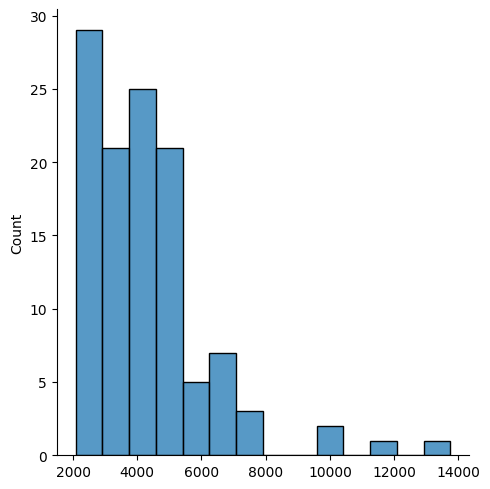

In [7]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Generate feature vectors by book

In [8]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,γυνή,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅς,ὅσος,ὅτε,ὑπό,ὕδωρ,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
Argonautica 1,1.153070,6.149707,1.249159,1.729605,5.284904,2.210051,1.249159,1.153070,45.546267,3.651388,...,0.576535,0.000000,25.079274,1.345248,5.861439,2.017873,1.441338,1.729605,0.960892,6.149707
Argonautica 2,1.212489,6.567647,1.414570,0.808326,5.759321,3.334344,0.808326,0.303122,46.983935,4.546832,...,0.909366,0.000000,25.260180,0.404163,5.658280,2.222896,1.010407,2.121855,0.606244,6.163484
Argonautica 3,1.332741,8.440693,1.066193,1.066193,4.264771,1.776988,1.865837,0.533096,48.867170,3.553976,...,0.533096,0.000000,23.722790,0.888494,4.886717,1.243892,0.888494,2.132386,0.710795,8.085295
Argonautica 4,1.091068,4.873436,1.891184,1.163806,5.600815,2.909514,1.018330,0.509165,44.806517,4.509747,...,0.290951,0.000000,22.766948,0.945592,6.837358,1.382019,1.309281,1.745708,1.309281,5.891766
Dionysiaca 1,0.000000,2.141328,0.535332,0.802998,3.211991,1.338330,0.802998,1.070664,35.064240,0.267666,...,1.338330,0.000000,4.550321,1.605996,0.802998,0.267666,1.338330,1.873662,2.944325,4.282655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Posthomerica 6,1.170275,4.095963,2.340550,0.780183,5.851375,1.755413,1.560367,0.585138,55.197972,3.510825,...,0.195046,0.390092,24.575775,0.195046,6.826604,1.755413,0.975229,2.535596,0.390092,9.362200
Posthomerica 7,1.220575,4.882302,2.092415,1.046207,5.579773,1.394943,1.394943,1.046207,48.474281,2.266783,...,0.174368,1.220575,20.226678,0.348736,6.625981,1.569311,2.266783,2.789887,0.174368,10.810811
Posthomerica 8,0.780234,2.340702,3.120936,0.000000,7.282185,2.860858,2.080624,0.000000,57.997399,1.820546,...,0.780234,0.260078,20.286086,0.260078,8.062419,1.040312,1.820546,3.120936,0.520156,10.403121


### Dimensionality reduction

In [9]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

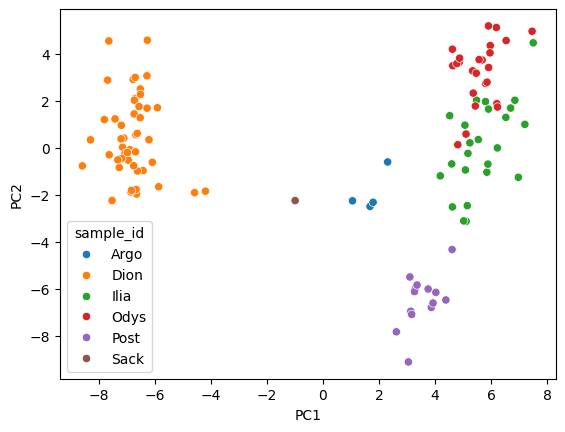

In [10]:
short_label = samples.index.str.slice(0,4)

fig, ax = plt.subplots()
sns.scatterplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,
)

plt.show()

### Examine loadings

In [11]:
loadings = pd.Series(model.components_[0], index=samples.columns)
loadings.abs().sort_values(ascending=False).head(15)

lemma
ὁ        0.162421
δή       0.153556
καί      0.150424
τε       0.149945
νῦν      0.146733
γε       0.146499
θυμός    0.145103
ὡς       0.144702
ἐπεί     0.142670
ἐν       0.141734
κατά     0.140901
δέ       0.138695
πᾶς      0.138108
μέν      0.137611
ἄρα      0.137408
dtype: float64

## Speech vs. Narrative

### Create new samples

In [12]:
# identify tokens spoken by characters/narrator
#  (omit Odysseus as Apologue narrator)
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
tokens["group"] = "oth"
tokens.loc[nr_mask, "group"] = "nar"
tokens.loc[sp_mask, "group"] = "spk"

# create samples
sample_size = 1000
for group in tokens["group"].unique():
    n_toks = sum(tokens["group"]==group)
    tokens.loc[tokens["group"]==group, "sample_id"] = np.random.permutation(n_toks) // sample_size
tokens["sample_id"] = tokens["group"] + "-" + tokens["sample_id"].map(str)

### Tokens per sample

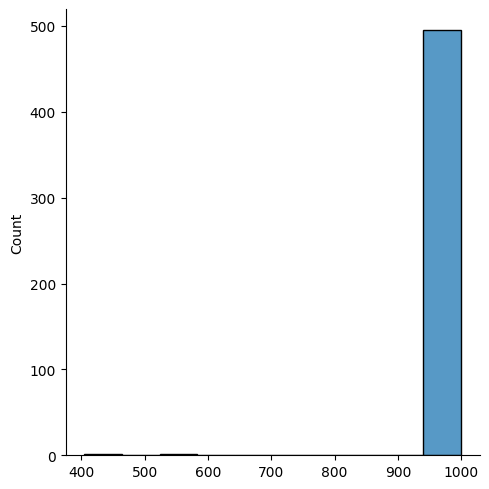

In [13]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Calculate feature vectors for each sample

In [14]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,γυνή,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅς,ὅσος,ὅτε,ὑπό,ὕδωρ,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
nar-0,2.0,4.0,3.0,1.0,4.0,2.0,1.0,0.0,48.0,1.0,...,0.0,0.0,26.0,1.0,6.0,1.0,2.0,3.0,1.0,8.0
nar-1,0.0,5.0,0.0,0.0,3.0,0.0,0.0,0.0,55.0,1.0,...,2.0,2.0,21.0,0.0,9.0,2.0,0.0,1.0,0.0,7.0
nar-10,0.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,56.0,1.0,...,3.0,3.0,23.0,2.0,4.0,0.0,2.0,2.0,1.0,8.0
nar-100,1.0,1.0,5.0,0.0,5.0,1.0,0.0,0.0,49.0,2.0,...,2.0,1.0,19.0,2.0,10.0,0.0,1.0,4.0,1.0,12.0
nar-101,1.0,2.0,2.0,2.0,7.0,0.0,1.0,1.0,46.0,1.0,...,1.0,0.0,28.0,0.0,7.0,0.0,2.0,5.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
spk-95,0.0,9.0,0.0,0.0,7.0,2.0,3.0,5.0,26.0,2.0,...,1.0,2.0,11.0,0.0,9.0,0.0,1.0,0.0,0.0,2.0
spk-96,0.0,2.0,1.0,1.0,7.0,2.0,1.0,4.0,29.0,4.0,...,1.0,3.0,14.0,0.0,6.0,1.0,0.0,1.0,0.0,7.0
spk-97,3.0,5.0,2.0,0.0,4.0,4.0,3.0,1.0,24.0,5.0,...,0.0,2.0,7.0,1.0,6.0,2.0,4.0,1.0,0.0,4.0


### Dimensionality reduction

In [15]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

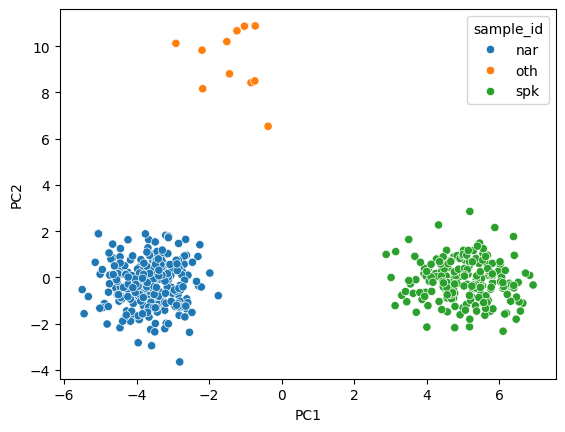

In [16]:
short_label = samples.index.str.slice(0,3)

fig, ax = plt.subplots()
sns.scatterplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,
)

plt.show()